In [1]:
import numpy
print(numpy.__version__)

1.21.0


In [2]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
from pydicom import dcmread
import os
import cv2
 # Keras specific
import keras
from keras.layers import Dense, Dropout, Flatten, concatenate
from keras.models import Sequential
from keras.utils import to_categorical 
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
import matplotlib.pyplot as plt


from sklearn.model_selection import StratifiedKFold
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence
import matplotlib.image as mpimg
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import tensorflow as tf
import tensorflow.keras.backend as K  


from keras.losses import binary_crossentropy

In [3]:
import albumentations as A
import cv2

C:\Users\James\AppData\Roaming\Python\Python38\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [4]:
#X_ray 由 WC WW 調控成像亮度，解剖照影(一致化病患亮度)。根據參考數據，進行轉換

def log_tran(image, wc, ww, bit):
    image = np.array(image)
    Max = wc + 0.5 * ww
    Min = wc - 0.5 * ww
    
    image = np.where(image > Max, Max, image)
    image = np.where(image < Min, Min, image)
    image = -1*np.log((image+1)/(2**bit))
    return image

#simplest color balance algorithm，調整過曝影像，忽略less relevent part of image

def simplest_balanced(image):
    image = image / 2.5
    image = np.where(image > 1, 1, image)
    image = np.where(image < 0, 0, image)
    
    return image

In [5]:
def bbox_trans(mask):
    # 初始化变量
    x1, y1, x2, y2 = 0, 0, 0, 0
    check = 0
    first = last = None
    
    # 遍历 mask 的每一行
    for i in range(1, len(mask)-1):  # 从1开始，避免 i-1 和 i+1 造成越界
        if 255 in mask[i] and 255 not in mask[i-1]:  # 找到前景区域的开始
            y1 = i
            first = mask[i]
            check = 1
        elif 255 in mask[i] and 255 not in mask[i+1]:  # 找到前景区域的结束
            y2 = i
            last = mask[i]
    
    if check:
        # 从第一行找到 x1 和 x2
        for j in range(1, len(first)-1):  # 从 1 开始，避免越界
            if first[j] != 0 and first[j-1] == 0:  # 找到第一列非零的像素
                x1 = j
            elif first[j] != 0 and first[j+1] == 0:  # 找到最后一列非零的像素
                x2 = j
    else:
        # 如果没有找到目标区域，返回默认值
        x1, y1, x2, y2 = 0, 0, 0, 0

    return [x1, y1, x2, y2]

In [6]:
train = pd.read_csv('C:/Users/James/Desktop/dlmia/hwk04_data/hwk04_data/train.csv',encoding = 'utf-8')

In [7]:
patients = {'TDR04_20180315_075734': {'cls': ['normal'], 'image': ['/normal/image/220_97.dcm'], 'mark': ['/normal/mark/220_97.dcm.jpg']}}

In [8]:
ID_list = ['TDR04_20180315_075734']

for i in range(1,len(train)):
    if train['ID'][i] not in ID_list:
        patients[train['ID'][i]] = {'cls': [train['category'][i]], 'image': [train['ImagePath'][i]], 'mark': [train['MarkPath'][i]]}
        ID_list.append(train['ID'][i])
    else:
        patients[train['ID'][i]]['cls'].append(train['category'][i])
        patients[train['ID'][i]]['image'].append(train['ImagePath'][i])
        patients[train['ID'][i]]['mark'].append(train['MarkPath'][i])


In [9]:
patients = pd.DataFrame.from_dict(patients, orient='index')
patients = patients.reset_index()

In [10]:
train_re = [[]]
images = []


for i in range(len(patients)):
    path = patients['image'][i][0]
    data = dcmread('C:/Users/James/Desktop/dlmia/hwk04_data/hwk04_data/train'+path)# 讀取 DICOM 檔案
    wc  = float(data[0x0028, 0x1050].value)
    ww = float(data[0x0028, 0x1051].value)
    bit = int(data[0x0028, 0x0101].value)
    slices = data.pixel_array
    slices = np.array(slices)
            
    slices = log_tran(slices, wc, ww, bit) #轉換
    slices = simplest_balanced(slices) #調整影像
    slices = cv2.resize(slices, (512,512))
    
    slices = (slices* 255).astype(np.uint8)
    
    slices = cv2.cvtColor(slices, cv2.COLOR_GRAY2BGR) #轉成 3 channel
    slices = slices / 255
    
    images.append(slices)
    
    
    if len(patients['cls'][i]) == 1:
        if patients['cls'][i][0] != 'normal':
            train_re[i].append([])
            mark_path = patients['mark'][i][0]
            ground_truth = mpimg.imread('C:/Users/James/Desktop/dlmia/hwk04_data/hwk04_data/train'+mark_path)
            ground_truth = cv2.resize(ground_truth, (512,512))
            train_re[i][0].append(bbox_trans(ground_truth))
            train_re[i][0].append(patients['cls'][i][0])
            
        else:
            train_re[i].append([])
            train_re[i][0].append([0, 0, 0, 0])
            train_re[i][0].append(patients['cls'][i][0])
        
        train_re.append([]) #下一個病患
        
    elif len(patients['cls'][i]) > 1:
        num = len(patients['cls'][i])
        
        for j in range(num):
            train_re[i].append([])
            
            mark_path = patients['mark'][i][j]
            ground_truth = mpimg.imread('C:/Users/James/Desktop/dlmia/hwk04_data/hwk04_data/train'+mark_path)
            ground_truth = cv2.resize(ground_truth, (512,512))
            train_re[i][j].append(bbox_trans(ground_truth))
            train_re[i][j].append(patients['cls'][i][j])
        
        train_re.append([]) #下一個病患
            
            
            

In [11]:
train_re = train_re[0:-1]

In [12]:
train_re #348病患

[[[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0

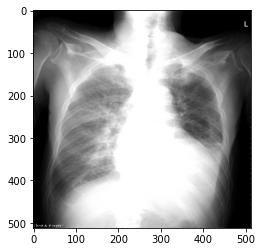

In [13]:
plt.imshow(images[200])

In [14]:
cat = []
for i in range(len(train_re)):
    for j in range(len(train_re[i])):
        if train_re[i][j][1] not in cat:
            cat.append(train_re[i][j][1])
k = {}
for i ,v in enumerate (cat):
    k.update({v : i})

In [15]:
k

{'normal': 0,
 '主動脈彎曲': 1,
 '肺野浸潤增加': 2,
 '肺尖肋膜增厚': 3,
 '胸椎退化性關節病變': 4,
 '主動脈硬鈣化': 5,
 '脊椎側彎': 6,
 '心臟肥大': 7}

In [16]:
train_re[0][0][1] #i病患 j個gt k(0, 1)

'normal'

In [17]:
train_re

[[[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0], 'normal']],
 [[[0, 0, 0, 0

In [18]:
for i in range(len(train_re)):
    for j in range(len(train_re[i])):
        cat = k[train_re[i][j][1]]
        train_re[i][j][1] = cat

In [19]:
train_re

[[[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 0, 0], 0]],
 [[[0, 0, 

In [41]:
transform = A.Compose([
    A.RandomCrop(width=450, height=450),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

In [42]:
image = images[190]


In [43]:
train_re[190]

[[[186, 192, 420, 389], 7], [[204, 21, 303, 438], 4]]

In [44]:
bboxes = [[186, 192, 420, 389], [204, 21, 303, 438]]

In [45]:
cls = ['7', '4']

In [46]:
bboxes

[[186, 192, 420, 389], [204, 21, 303, 438]]

In [47]:


# 使用 albumentations 增强图像和边界框

augmented = transform(image=image, bboxes=bboxes, class_labels=cls)

# 获取增强后的图像和边界框
augmented_image = augmented['image']
augmented_bboxes = augmented['bboxes']

In [48]:
augmented_bboxes

[[81.0, 170.0, 315.0, 367.0], [198.0, 0.0, 297.0, 416.0]]

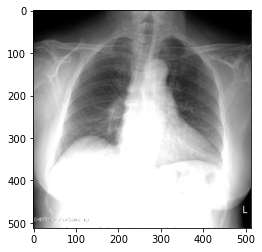

In [50]:
plt.imshow(image)

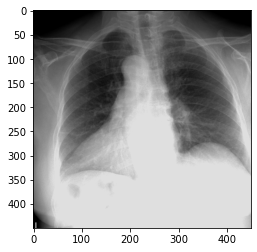

In [49]:
plt.imshow(augmented_image)

In [ ]:
#計算Iou a座標(x1, y1, x2, y2)

def intersection(a1, a2): 
    x = max(a1[0], a2[0])
    y = max(a1[1], a2[1])
    w = min(a1[2], a2[2]) - x
    h = min(a1[3], a2[3]) - y
    
    if w < 0 or h < 0:
        return 0
    return w * h  #面積 

def union(a1, a2):
    area1 = (a1[2] - a1[0]) * (a1[3] - a1[1]) 
    area2 = (a2[2] - a2[0]) * (a2[3] - a2[1])
    
    area_union = area1 + area2 - intersection(a1, a2)
    return area_union

def get_iou(a1, a2):
    if a1[0] > a1[2]:
        a1[0], a1[2] = a1[2], a1[0]
        
    if a1[1] > a1[3]:
        a1[1], a1[3] = a1[3], a1[1]
    
    if a2[0] > a2[2]:
        a2[0], a2[2] = a2[2], a2[0]
    
    if a2[1] > a2[3]:
        a2[1], a2[3] = a1[3], a2[1]
        
    area_i = float(intersection(a1,a2))
    area_u = float(union(a1,a2))
    
    if area_u <= 0:
        return 0
    
    return area_i / area_u

In [ ]:
#生成 anchor
def create_anchor(size = (64,128,256), ratios =(0.5, 1, 2)):
    anchors = []
    
    for r in ratios:
        s1 = [round(x * x * r) ** 0.5 for x in size]
        s2 = [round(s / r) for s in s1]
        
        
        for i in range(len(size)):
            anchors.append((-s1[i]//2, -s2[i]//2, s1[i]//2, s2[i]//2))
    return anchors

In [ ]:
anchor_box = create_anchor()
anchor_box

In [ ]:
feature_size = ( 512 // 16, 512 // 16) #512 * 512經VGG16出來feature map縮小16倍

In [ ]:


def create_train_anchors(feature_size, base_anchors, stride):
    anchors = []
    
    for r in range(feature_size[0]):
        for c in range(feature_size[1]):
            for a in base_anchors:
                anchors.append([c*stride + stride // 2 + a[0],
                                r*stride + stride // 2 + a[1],
                                c*stride + stride // 2 + a[2],
                                r*stride + stride // 2 + a[3]])
    return anchors

In [ ]:
#32*32*9 anchor box
All_anchors = create_train_anchors(feature_size, anchor_box, 16)

In [ ]:
len(All_anchors)

# 打印標籤

In [ ]:
def generate_rpn_samples(anchor_boxes, ground_truth_boxes):
    cls_label = []
    iou_matrix = []
    
    for anchor in anchor_boxes:
        row_iou = []
        # 比較每個 anchor box 與所有 ground truth box，計算 IoU
        for gt_box in ground_truth_boxes:
            #防止超出邊線
            anchor[0] = max(0, anchor[0])
            anchor[1] = max(0, anchor[1])
            anchor[2] = min(511, anchor[2])
            anchor[3] = min(511, anchor[3])
            
            
            iou = get_iou(anchor, gt_box)
            row_iou.append(iou)
        iou_matrix.append(row_iou)
        
    for r in iou_matrix:
        a_max = max(r)
        
        if (a_max > 0.6):
            gt = ground_truth_boxes[r.index(a_max)]
            cls_label.append((1, gt))
        
        elif (0 <= a_max <= 0.3):
            cls_label.append((0, [0, 0, 0, 0]))
        else:
            cls_label.append((-1, [0, 0, 0, 0]))
            
    for g in range(len(ground_truth_boxes)):
        max_iou = 0
        for a in range(len(anchor_boxes)):
            if iou_matrix[a][g] > max_iou:
                max_iou = iou_matrix[a][g]
                
        if 0 < max_iou < 0.6: # gt max_iou <0.7(no pos) 設為pos樣本
            for a in range(len(anchor_boxes)):
                if iou_matrix[a][g] > max_iou:
                     cls_label[a] = ((1, ground_truth_boxes[g]))
                        
    pos = [i for i, x in enumerate(cls_label) if 1 == x[0]]  #get index of pos anchors
    neg = [i for i, x in enumerate(cls_label) if 0 == x[0]]  
    
    np.random.shuffle(pos)
    np.random.shuffle(neg)
    
    pos_num = min(len(pos), 128) #每張圖套用256anchor， 正樣本數 184 
    
    for p in pos[pos_num:]:
        cls_label[p] = (-1,[0, 0, 0, 0]) #刪除多餘正樣本
    
    neg_num = 256 - pos_num #負樣本數 
    
    for n in neg[neg_num:]:
        cls_label[n] = (-1,[0, 0, 0, 0]) #刪除多餘負樣本
    
    
    cls_id = []
    gt_boxes = []
    #最終回傳每個 anchors是何種樣本和對應GT
    for labels in cls_label:
        cls_id.append(labels[0])
        gt_boxes.append(labels[1])
    
    cls_id = np.array(cls_id)
    gt_boxes = np.array(gt_boxes)
    
    return cls_id, gt_boxes

# reg labels

In [ ]:
def get_reg_label(anchors, cls_label, gt_boxes):
    reg_labels = [8.0] * len(cls_label) * 4
    
    for i, a in enumerate(anchors):
        if cls_label[i] != 1:
            continue
            
        w_a = a[2] - a[0]
        h_a = a[3] - a[1]
        ax_center = (a[2] + a[0]) * 0.5
        ay_center = (a[3] + a[1]) * 0.5
        
        gt = gt_boxes[i]
        
        gt_w = gt[2] - gt[0]
        gt_h = gt[3] - gt[1]
        gtx_center = (gt[2] + gt[0]) * 0.5
        gty_center = (gt[3] + gt[1]) * 0.5
        
        reg_labels[(i << 2) + 0] = (gtx_center - ax_center) / w_a
        reg_labels[(i << 2) + 1] = (gty_center - ay_center) / h_a
        reg_labels[(i << 2) + 2] = np.log(gt_w / w_a)
        reg_labels[(i << 2) + 3] = np.log(gt_h / h_a)
        
    return reg_labels

In [ ]:
train_re[190]

In [ ]:
plt.imshow(images[190])

In [ ]:
for i, v in train_re[190]:
    cv2.rectangle(images[190], (int(i[0]), int(i[1])), (int(i[2]), int(i[3])), (0, 255, 0), 2)
    
cv2.imshow('Image with Bounding Box', images[190])

# 等待按鍵來關閉視窗
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
train_re

In [ ]:
train_re

In [ ]:
cls = []
for i in range(len(train_re)):
    syn = []
    for j in range(len(train_re[i])):
        syn.append(train_re[i][j][1])
    cls.append(syn)

In [ ]:
images = np.array(images)
images.shape

In [ ]:
cls = np.array(cls)
cls.shape

In [ ]:
gt = []
for i in range(len(train_re)):
    bbox = []
    for j in range(len(train_re[i])):
        xmin, ymin, xmax, ymax = train_re[i][j][0]
        gt_image = np.zeros((512, 512), dtype=np.uint8)
        xmin = max(0, xmin)
        ymin = max(0, ymin)
        xmax = min(512, xmax)
        ymax = min(512, ymax)
        gt_image[ymin:ymax, xmin:xmax] = 1
        bbox.append(gt_image)
    gt.append(bbox)

In [ ]:
plt.imshow(gt[190][1])

In [ ]:
gt = np.array(gt)
gt.shape

# Data augmentation

In [ ]:
train_re # (x1, y1, x2, y2)

In [ ]:
class InputGenerator(Sequence):
    """Wrapper of 2 ImageDataGenerator"""

    def __init__(self, X1, y, anchor_boxes, rcnn_cls, batch_size):
         # Keras generator
        self.generator = ImageDataGenerator(
                                            horizontal_flip=True,
                                            width_shift_range=0.1,
                                            height_shift_range=0.1,
                                            zoom_range=0.1,
                                            fill_mode='nearest')

            # Real time multiple input data augmentation
        self.genX1 = self.generator.flow(X1,rcnn_cls, batch_size=batch_size, seed=1)
        self.geny = self.generator.flow(y, batch_size=batch_size, seed=1)
        self.anchor_boxes = anchor_boxes

    def __len__(self):
        """It is mandatory to implement it on Keras Sequence"""
        return self.genX1.__len__()

    def __getitem__(self, index):
        """Getting items from the 2 generators and packing them"""
        X1_batch = self.genX1.__getitem__(index)
        gt_aug = self.geny.__getitem__(index)
        
        box_trans = []
        cls_labels_batch = []
        gt_boxes_batch = []
        reg_labels_batch = []
        rcnn_reg = []
        # Loop to get multiple samples or process each sample
        for i in range(len(gt_aug)):
            # Generate classification labels and bounding boxes for each sample
            
            indexs = bbox_trans(gt_aug[i]) #轉座標
            rcnn_reg.append(indexs) #GT_aug 座標輸出
            
            box_trans.append(indexs)
            
            cls_labels, gt_boxes = generate_rpn_samples(self.anchor_boxes, box_trans)
            cls_labels = np.float32(cls_labels)
            
            reg_labels = get_reg_label(self.anchor_boxes, cls_labels, gt_boxes)
            
            cls_labels_batch.append(cls_labels)
            reg_labels_batch.append(reg_labels)
            gt_boxes_batch.append(gt_boxes)
            box_trans = []
            
        cls_labels_batch = np.array(cls_labels_batch)
        gt_boxes_batch = np.array(gt_boxes_batch)
        reg_labels_batch = np.array(reg_labels_batch)
        rcnn_reg = np.array(rcnn_reg)
        cls_labels_batch = np.reshape(cls_labels_batch,(len(gt_aug),32,32,9))
        reg_labels_batch = np.reshape(reg_labels_batch,(len(gt_aug),32,32,36))
        
        
        
        images = X1_batch[0]  # The image data is the first part of the batch
        rcnn_cls = X1_batch[1]  # The class labels for RPN
        
        
        return [images, rcnn_cls, rcnn_reg], [cls_labels_batch, reg_labels_batch, rcnn_cls, rcnn_reg]

In [ ]:

rcnn_cls = []

for i,v in cat:
    rcnn_cls.append(v)
rcnn_cls = np.array(rcnn_cls)


In [ ]:
X1 = []
y = []
for i in range(len(x)):
    img = np.array(x[i][0])
    img = (img* 255).astype(np.uint8)
    
    slices = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) #轉成 3 channel
    slices = slices / 255
    
    X1.append(slices)
    label = x[i][1]
    label = label.reshape((512, 512, 1))

    y.append(label)

In [ ]:
X1 = np.array(X1)
X1.shape

In [ ]:
y = np.array(y)

In [ ]:
X1.shape, y.shape

In [ ]:
rcnn_cls.shape

In [ ]:
example = InputGenerator(X1, y, All, rcnn_cls, 4)

In [ ]:
ex1 = example[0]

In [ ]:
ex1[1][0].shape

In [ ]:
ex1[1][1].shape

In [ ]:
ex1[1][2].shape

In [ ]:
ex1[1][3].shape

In [ ]:


def rpn_cls_loss(y_true, y_pred):
    
    mask = tf.cast(y_true > -1, dtype = tf.float32) #非中性樣本
    
    loss = K.sum(mask * K.binary_crossentropy(y_true, y_pred)) / (1e-6 + K.sum(mask))
    
    return loss



In [ ]:
def rpn_cls_acc(y_true, y_pred):
    
    idxs = tf.where(K.not_equal(y_true, -1))
    
    y_true = tf.gather_nd(y_true, idxs)
    y_pred = tf.gather_nd(y_pred, idxs)
    
    acc = keras.metrics.binary_accuracy(y_true, y_pred, threshold = 0.5)
    
    return acc

In [ ]:


def rpn_reg_loss(y_true, y_pred):
    
    mask = tf.cast(y_true < 8.0, dtype = tf.float32) #非中性樣本
    offset = mask * K.abs(y_true - y_pred)
    
    les = tf.cast(offset <= 1, dtype = tf.float32)
    loss = K.sum(les * 0.5 * offset ** 2 + (1 - les) * (offset - 0.5)) / (1e-6 + K.sum(mask))
    
    return loss



In [ ]:
def rpn_reg_acc(y_true, y_pred):
    
    mask = tf.cast(y_true < 8.0, dtype = tf.float32) #非中性樣本
    offset = mask * K.abs(y_true - y_pred)
    
    of = mask * K.abs(y_true)
    acc = 1 - K.sum(offset / (1e-6 + K.sum(of)))  
    
    return acc

# Model (VGG_5block) feature map (最後一層不用pooling)

# RPN Network 產出proposal (分兩路: bbox大小 and anchor box分類與得分)

# layer1 3*3*512 conv2D ()





# feature map 每一點9個anchor判別。
# (x,y) 偏移係數(離gt中心) (w,h) 縮放係數(包住) 

In [ ]:
import tensorflow as tf

# ROI proposal (nms篩選proposal，送至roi pooling layer)

In [ ]:
class RPNProposalLayer(tf.keras.layers.Layer):
    def __init__(self, base_anchors, stride = 16, num_proposals =256, iou_threshold=0.7, **kwargs):
        
        super(RPNProposalLayer, self).__init__(**kwargs)
        
        self.num_proposals = num_proposals  # 顯示我們需要的proposal數量
        self.iou_threshold = iou_threshold  # 非極大值抑制(NMS)的閾值
        self.stride = stride 
        self.base_anchors = tf.constant(base_anchors, dtype = tf.float32)  
        self.AnchorDim = 4 
        self.K = len(base_anchors)  
        
        
    def build(self, input_shape):
        super(RPNProposalLayer, self).build(input_shape)    
        
    
    def generate_anchors_tf(self, batch_size, feature_shape = (32, 32)):
        """
        在 TensorFlow 中 映射特徵圖base Anchor Box位置回到原圖位置。
        """
        
        
        rows = feature_shape[0]
        cols = feature_shape[1]
            
        # 生成網格的中心點 (每個像素點的中心位置)
        ax = (tf.cast(tf.range(cols), dtype=tf.float32)) * self.stride + 0.5 * self.stride   # 水平坐標
        ay = (tf.cast(tf.range(rows), dtype=tf.float32)) * self.stride + 0.5 * self.stride   # 水平坐標
        
        ax = tf.cast(ax, dtype=tf.float32)  # 确保类型为 float32
        ay = tf.cast(ay, dtype=tf.float32)  # 确保类型为 float32
        
        
        ax, ay = tf.meshgrid(ax, ay)  # 網格網格化
    
        # 將網格展平成一維
        ax = tf.reshape(ax, (-1, 1))  # [height * width]
        ay = tf.reshape(ay, (-1, 1))  # [height * width]
    
    
        anchor = tf.stack([ax,ay,ax,ay],axis = -1) #中心點位置
        anchor_boxes = anchor + self.base_anchors
        #shape (32*32, 9, 4) ， 對不上batch_size,四座標
            
        anchor_boxes = tf.reshape(anchor_boxes, (32, 32, self.K, self.AnchorDim))
        anchor_boxes = tf.expand_dims(anchor_boxes, axis= 0)
        anchor_boxes = tf.tile(anchor_boxes, [batch_size, 1, 1, 1, 1])
            
        #shape (4, 32*32, 9, 4) ，
    
        return anchor_boxes
    
    def get_boxes(self, batch_size, feature_shape, targets, boxes, deltas):
        """
        
        scores == 9個anchors中最大值 #  (batch_size, 32, 32,)
        
        boxes == 對應anchor_boxes  (batch_size, 32, 32, 4)
        
        deltas == 對應修正參數 shape (batch_size, 32, 32, 9, 4)
        
        target == cls分數 (b, 32, 32, 9)
        """
        scores = tf.reduce_max(targets, axis=-1) #找K個anchors中最大數。 
        
        scores_re = tf.repeat(scores, self.K, axis=-1)
        
        scores_re = tf.reshape(scores_re, (batch_size, 32, 32, self.K))
        targets = tf.reshape(targets, (batch_size, 32, 32, self.K)) 
        valid_mask = tf.greater_equal(targets, scores_re) #(batch_size, 32, 32, 4)
        
        boxes = tf.boolean_mask(boxes, valid_mask, axis = 0) #true for max 
            
        deltas = tf.reshape(deltas, (batch_size, feature_shape[0], feature_shape[1], self.K, self.AnchorDim))
        deltas = tf.boolean_mask(deltas, valid_mask, axis = 0)
            
    
        return scores, boxes, deltas
    
    
    
    
    
    
    def box_delta(self, image_shape, anchors, deltas):
        w = anchors[..., 2] - anchors[..., 0]
        h = anchors[..., 3] - anchors[..., 1]
        x = anchors[..., 0] + w *0.5 
        y = anchors[..., 1] + h *0.5 

        #修正anchor
        
        x += deltas[..., 0] + w * 0.5
        y += deltas[..., 1] + h * 0.5
        w = tf.exp(deltas[..., 2])
        h = tf.exp(deltas[..., 3])
    
        x1 = x - w * 0.5
        x2 = x + w * 0.5
        y1 = y - h * 0.5
        y2 = y + h * 0.5
        
        #截斷超出圖片
        x1 = tf.maximum(0.0, x1)
        y1 = tf.maximum(0.0, y1)
        x2 = tf.minimum(x2, tf.cast(image_shape[1] - 1, dtype = tf.float32))
        y2 = tf.minimum(y2, tf.cast(image_shape[0] - 1, dtype = tf.float32))
        
        anchor_box = tf.stack([y1, x1, y2, x2], axis = -1) #tf順序y先放
        
        return anchor_box
        
        
        
        
    def box_padding(self, image_shape, boxes, pad_num):
        rows = tf.cast(image_shape[0], dtype = tf.float32)
        cols = tf.cast(image_shape[1], dtype = tf.float32)
        #確保 x2>x1 y2>y1
        space = tf.cast(tf.random.uniform(shape = (), minval = 16, maxval = 64),dtype = tf.float32)
        
        
        x1 = tf.random.uniform(shape = (pad_num, 1), minval = 0, maxval = cols - space)
        y1 = tf.random.uniform(shape = (pad_num, 1), minval = 0, maxval = rows - space)
        x2 = tf.random.uniform(shape = (pad_num, 1), minval = x1 + space, maxval = cols)
        y2 = tf.random.uniform(shape = (pad_num, 1), minval = y1 + space, maxval = rows)
        
        random_boxes = tf.concat((y1,x1,y2,x2),axis = -1)
        random_boxes = tf.reshape(random_boxes, (-1, self.AnchorDim))
        boxes = tf.concat((random_boxes, boxes),axis = 0)
        
        return boxes
        
        
        
        
    def batch_process(self, image_shape, boxes, scores, i):
        indices = tf.image.non_max_suppression(boxes[i], 
                                               scores[i],
                                               self.num_proposals,
                                              self.iou_threshold)
        
        selected_boxes = tf.gather(boxes[i], indices)
        num_boxes = tf.shape(selected_boxes)[0]
        pad_num = self.num_proposals - num_boxes
        
        selected_boxes = tf.cond(num_boxes < self.num_proposals,
                                lambda: self.box_padding(image_shape, selected_boxes, pad_num),
                                lambda: selected_boxes)
        return selected_boxes
    
    def compute_output_shape(self, input_shape):
        # 假設 batch_size 和圖像形狀已經確定，返回靜態輸出形狀
        batch_size = input_shape[0][0]  # 批量大小
        return (batch_size, self.num_proposals, self.AnchorDim)
        
    def call(self, inputs):
        # 功能一創建 base anchors
        # 功能二修正 anchors
        # 功能三 NMS
        
        image, targets, deltas = inputs #target cls結果
        batch_size = tf.shape(image)[0]
        image_shape = tf.shape(image)[1:3]
        feature_shape = tf.shape(targets)[1:3]
        
        anchor_boxes = self.generate_anchors_tf(batch_size, feature_shape)
        
        
        scores, boxes, deltas = self.get_boxes(batch_size, feature_shape, targets, anchor_boxes, deltas)
        anchor_boxes = self.box_delta(image_shape, boxes, deltas)
        '''
        selected_boxes = tf.map_fn(
        lambda i: self.batch_process(image_shape,
                                     tf.reshape(anchor_boxes, (batch_size, -1, self.AnchorDim)),
                                     tf.reshape(scores, (batch_size, -1)),
                                     i),
            tf.range(batch_size, dtype = tf.int32),
            dtype = tf.float32,
            back_prop = False)
        
        anchor_boxes = tf.reshape(selected_boxes, (batch_size, -1, self.AnchorDim))
        
        '''
        selected_boxes = tf.nest.map_structure(
            tf.stop_gradient, 
            tf.map_fn(lambda i: self.batch_process(image_shape,tf.reshape(anchor_boxes, (batch_size, -1, self.AnchorDim)),
            tf.reshape(scores, (batch_size, -1)),i),
        tf.range(batch_size, dtype=tf.int32),
        dtype=tf.float32))
        
        selected_boxes = tf.reshape(selected_boxes, [batch_size, self.num_proposals, self.AnchorDim])
        
        return selected_boxes
    
    

In [ ]:
class ROIPoolingLayer(tf.keras.layers.Layer):
    def __init__(self, pool_size, **kwargs):
        self.pool_size = (7, 7)  # 池化後的大小 (h, w)
        super(ROIPoolingLayer, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.feature_channels = input_shape[1][3]
        super(ROIPoolingLayer, self).build(input_shape)
        
    def call(self, inputs):
        """
        inputs: 
          image [batch_size, height, width, channels]
        - feature_map: [batch_size, height, width, channels] 來自CNN的特徵圖
        - rois: [num_rois, 4] 每個RoI的座標 (x1, y1, x2, y2)
        
        """
        images, feature_map, rois = inputs
        image_shape = tf.shape(images)[1:3]
        batch_size = tf.shape(feature_map)[0]
        num_rois = tf.shape(rois)[1]
        
        roi_shape = tf.shape(rois)
        
        feature_shape = tf.shape(feature_map)
        
        feature_channels = self.feature_channels
        
        y_scale = 1.0 / tf.cast(image_shape[0] -1, dtype = tf.float32)
        x_scale = 1.0 / tf.cast(image_shape[1] -1, dtype = tf.float32)
        
        
        y1 = rois[..., 0]
        x1 = rois[..., 1]
        y2 = rois[..., 2]
        x2 = rois[..., 3]
        
        rois = tf.stack([y1, x1, y2, x2], axis = -1)
        
        indices = tf.range(batch_size, dtype = tf.int32)
        indices = tf.repeat(indices, num_rois, axis = -1)
        
        rois = tf.reshape(rois, (-1, roi_shape[-1]))
        
        crops = tf.image.crop_and_resize(image = feature_map,
                                        boxes = rois,
                                        box_indices = indices,
                                        crop_size = self.pool_size,
                                        method = 'bilinear')
        
        crops = tf.reshape(crops, (batch_size, num_rois, self.pool_size[0], self.pool_size[1], feature_channels))
        return crops
    def compute_output_shape(self, input_shape):
        image_shape, feature_shape, roi_shape = input_shape
        batch_size = image_shape[0]
        num_roi = roi_shape[1]
        feature_channel = self.feature_channels
        return (batch_size, num_rois, self.pool_size[0], self.pool_size[1], feature_channels)

In [ ]:
class ProposalLabel(tf.keras.layers.Layer):
    def __init__(self, iou_threshold=0.5, flags = 8.0, **kwargs):
        self.iou_threshold = iou_threshold  # Anchors 的尺度列表
        self.flags = flags  # 正負樣本判定的 IoU 閾值
        super(ProposalLabel, self).__init__(**kwargs)
 
    
    def build(self, input_shape):
        super(ProposalLabel, self).build(input_shape)
    
       
    def call(self, inputs):
        """
        
        """
        proposals, cls_true, reg_true = inputs
        
        ious = self.calculate_iou(proposals, reg_true)
        rcnn_cls = self.get_cate(ious, cls_true)
        rcnn_reg = self.get_reg(ious, proposals, reg_true)
        
        return [rcnn_cls, rcnn_reg]
    
    def compute_output_shape(self, input_shape):
        
        return [(input_shape[0][0], input_shape[0][1], 1), input_shape[0]]
    
    
    
    
    def calculate_iou(self, proposals, reg_true):
        
        #採用dim expand計算iou
        
        proposals = tf.expand_dims(proposals, axis =2)
         # shape = (b, num_proposal , 1, 4)
        reg_true = tf.expand_dims(reg_true, axis =1)
        # shape = (b, 1 , num_ture, num)
        
        
        
        p_y1, p_x1, p_y2, p_x2 = tf.unstack(proposals, axis = -1)
        true_x1, true_y1, true_x2, true_y2 = tf.unstack(reg_true, axis = -1)
        
        
        # 計算交集
        inter_x1 = tf.maximum(p_x1, true_x1)
        inter_y1 = tf.maximum(p_y1, true_y1)
        inter_x2 = tf.minimum(p_x2, true_x2)
        inter_y2 = tf.minimum(p_y2, true_y2)
        
        w = tf.maximum(0.0, inter_x2 - inter_x1)
        h = tf.maximum(0.0, inter_y2 - inter_y1)
        
        inter_area = w * h

        # 計算聯集
        proposal_area = (p_x2 - p_x1) * (p_y2 - p_y1)
        true_area = (true_x2 - true_x1) * (true_y2 - true_y1)
        #ious_shape == (b, num_proposal, num_reg)
        ious = tf.where(tf.equal(proposal_area + true_area, 0),
                        tf.zeros_like(inter_area),
                        inter_area / (proposal_area + true_area - inter_area + 1e-8))
        
        return ious
    
    
    def get_cate(self, ious, cls_true):
        """
        """
        max_ious = tf.reduce_max(ious, axis=-1) #找K個anchors中最大數。 
        
        max_indices = tf.argmax(ious, axis=-1)#返回最大值位置
        
        y_true = tf.gather(cls_true, max_indices, axis = 1, batch_dims =1)#根據indices反回cls
        y_shape = tf.shape(y_true)
        
        mask = tf.cast(max_ious >= self.iou_threshold, dtype = tf.float32)
        
        mask = tf.reshape(mask, (y_shape[0], y_shape[1], 1))
        
        y_true = tf.reshape(y_true, (y_shape[0], y_shape[1], 1))
        
        y_true = y_true * mask #只保留大於iou threshold的分類
        
        return y_true
    
    def get_reg(self, ious, proposals, reg_true):
        """
        計算每個 anchor 和 ground truth 框的 IoU。
        """
        max_ious = tf.reduce_max(ious, axis=-1) #找K個anchors中最大數。 
        
        max_indices = tf.argmax(max_ious, axis=-1)
        
        reg_true = tf.gather(reg_true, max_indices, axis = 1, batch_dims =1)
        
        #proposal之框
        proposals_w = proposals[..., 3] - proposals[..., 1]
        proposals_h = proposals[..., 2] - proposals[..., 0]
        
        proposal_x = proposals[..., 1] + proposals_w * 0.5 
        proposal_y = proposals[..., 0] + proposals_h * 0.5 

        #true之框
        
        reg_true_w = reg_true[..., 2] - reg_true[..., 0]
        reg_true_h = reg_true[..., 3] - reg_true[..., 1]
        
        reg_true_x = reg_true[..., 0] + reg_true_w * 0.5 
        reg_true_y = reg_true[..., 1] + reg_true_h * 0.5 
        
        p_mask = tf.cast(max_ious >= self.iou_threshold, dtype = tf.float32)
        n_mask = tf.cast(max_ious < self.iou_threshold, dtype = tf.float32) * self.flags
        
        
        dx = (reg_true_x - proposal_x) / reg_true_w * p_mask + n_mask
        dy = (reg_true_y - proposal_y) / reg_true_h * p_mask + n_mask
        dw = tf.math.log(reg_true_w / proposals_w) * p_mask + n_mask
        dh = tf.math.log(reg_true_h / proposals_h) * p_mask + n_mask
        
        y_true = tf.stack([dx, dy, dw, dh],axis = -1)
        return y_true
        
        

In [ ]:
from tensorflow.keras.layers import TimeDistributed, Conv2D, Flatten, Dense

In [ ]:
def faster_rcnn(input_shape, num_anchors,base_anchors):
    # Load the pre-trained VGG16 model (without the classification layers)
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
   
    # Freeze the layers of VGG16 to prevent training on them
    for layer in base_model.layers:
        layer.trainable = False
    
    # Use the output of the last convolutional block as fea
    x = base_model.get_layer('block5_conv3').output  #5block cov output (no max pooling)
    
    y_cls = keras.layers.Input(shape = (None, 1), name = 'input_class')
    y_boxes = keras.layers.Input(shape = (None, 4), name = 'input_boxes')
    
    
    # RPN: A convolutional layer for bounding box regression (output: 4 coordinates for each anchor box)
    rpn_bbox = keras.layers.Conv2D(filters = 512,
                            kernel_size = (3, 3),
                            padding = 'same',
                            activation = 'relu',
                            name = 'rpn_conv')(x)
    
    
    # RPN: regression
    rpn_reg = tf.keras.layers.Conv2D(num_anchors * 4,
                            kernel_size = (1, 1),
                            kernel_initializer = 'zero',
                            activation = 'linear',
                            name = 'rpn_reg')(rpn_bbox)
    
    rpn_cls = tf.keras.layers.Conv2D(filters = num_anchors,
                            kernel_size=(1, 1),
                            activation='sigmoid',
                            kernel_initializer = 'uniform',
                            name='rpn_cls')(rpn_bbox)
    
    
    proposal_layer = RPNProposalLayer(All, stride = 16, num_proposals =256, iou_threshold=0.7)
    
    # Get the final proposals by connecting the proposal layer to the RPN's outputs
    proposals = proposal_layer([base_model.input, rpn_cls, rpn_reg])
    
    
    roi_pooling = ROIPoolingLayer((7, 7))([base_model.input, x, proposals])
    
    
    label_layer = ProposalLabel(0.5, 8.0, name ='roi_label')
    cls_true, cls_reg = label_layer([proposals, y_cls, y_boxes])
    
    flatten = TimeDistributed(Flatten(), name = 'roi_flatten')(roi_pooling)
    

    fc1 = TimeDistributed(Dense(2048, kernel_initializer = 'uniform', activation = 'relu'),name = 'fc1')(flatten)
    fc2 = TimeDistributed(Dense(2048, kernel_initializer = 'uniform', activation = 'relu'),name = 'fc2')(fc1)
    
    rcnn_cls = TimeDistributed(Dense(8, kernel_initializer = 'uniform', activation = 'softmax'),name = 'cls')(fc2)
    
    rcnn_reg = TimeDistributed(Dense(4, kernel_initializer = 'zero', activation = 'linear'),name = 'reg')(fc2)
    
    
    cls_concat = keras.layers.Concatenate(axis = -1, name = 'cls_concat')([rcnn_cls, cls_true])
    reg_concat = keras.layers.Concatenate(axis = -1, name = 'reg_concat')([rcnn_reg, cls_reg])
    
    # Define the final model
    model = Model(inputs=[base_model.input, y_cls, y_boxes], outputs= [rpn_cls, rpn_reg, cls_concat, reg_concat])

    
    return model

# Build the model
faster_rcnn_model = faster_rcnn((None, None, 3), 9, All)

# Display the model architecture
faster_rcnn_model.summary()

# Roi pooling 將不同大小proposals轉為相同size feature map加以後續訓練

# TRAIN

In [ ]:
rpn_model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
                 loss = [rpn_cls_loss, rpn_reg_loss],
                 loss_weights = [1.0, 10.0],
                 metrics = [rpn_cls_acc, rpn_reg_acc])

In [ ]:
def callbacks():
    early = EarlyStopping(monitor="val_loss", min_delta=0, patience=20, verbose=0, mode="max")
    filepath="C:\\Users\\James\\proposal_models" # Path to save the trained models
    checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', save_best_only=True, mode='max') #creating checkpoint to save the best validation accuracy
    return [early, checkpoint]

In [ ]:
ca = callbacks()

In [ ]:
epoch = 1
batch_size = 4

train = InputGenerator(X1, y, All, 4)


history = rpn_model.fit(train,

    epochs = epoch,
    steps_per_epoch=len(X1) // batch_size,
    verbose = 1)

In [ ]:
test = pd.read_csv('C:/Users/James/Desktop/dlmia/hwk04_data/hwk04_data/test.csv',encoding = 'utf-8')

In [ ]:

data = dcmread('C:/Users/James/Desktop/dlmia/hwk04_data/hwk04_data/test' + test['ImagePath'][50])
wc  = float(data[0x0028, 0x1050].value)
ww = float(data[0x0028, 0x1051].value)
bit = int(data[0x0028, 0x0101].value)


In [ ]:
slices = data.pixel_array
slices = np.array(slices)
slices = log_tran(slices, wc, ww, bit) #轉換
slices = simplest_balanced(slices) #調整影像
slices = cv2.resize(slices, (512,512))

In [ ]:
img_rgb_array = np.stack([slices] * 3, axis=-1)
img_rgb_array = np.expand_dims(img_rgb_array, axis=0)

In [ ]:
a = rpn_model.predict(img_rgb_array)

In [ ]:
a[0].shape

In [ ]:
a[1].shape

In [ ]:
scores = tf.reduce_max(a[0], axis=-1)
scores.shape

In [ ]:
#(4,32,32,9) cls shape

#(4,32,32,36)

In [ ]:
scores_re = tf.repeat(scores, 9, axis=-1)
scores_re

In [ ]:
score_re = tf.reshape(scores_re,(1,32,32,9))

In [ ]:
score_re.shape

In [ ]:
            
valid_mask = tf.greater_equal(a[0], score_re) 

In [ ]:
valid_mask